# 08_Correlation_and_Covariance

### What are Correlation and Covariance?

Correlation and Covariance measure how two variables move together — whether they increase together, move oppositely, or show no relationship at all.

Simply put, they help us understand relationships between variables before building models.

Topics covered: Correlation, Covariance, Positive Correlation, Negative Correlation, No Correlation, Pearson Correlation, Spearman Correlation, Correlation Matrix, Heatmap.

## 01. Correlation

**Definition**: Correlation measures the strength and direction of the linear relationship between two variables, indicating how they move together.

**Formula**: r = Cov(X,Y) / (σ_X × σ_Y), ranges from -1 to +1

**Where it is used**: Used in feature selection, exploratory data analysis, finance, and identifying relationships between variables before modeling.

**Real-World Example**: Height and weight of individuals tend to be correlated — taller people generally weigh more.

**AI/ML Example**: Checking correlation between features helps detect multicollinearity before fitting a regression model.

In [1]:
import numpy as np

x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 5, 4, 5])
corr = np.corrcoef(x, y)[0, 1]
print("Correlation:", corr)

Correlation: 0.7745966692414834


**Interpretation**: The correlation coefficient (~0.77) indicates a strong positive linear relationship between x and y.

## 02. Covariance

**Definition**: Covariance measures the direction of the linear relationship between two variables — whether they increase or decrease together — but not the strength, since it is unscaled.

**Formula**: Cov(X,Y) = Σ[(x_i − x̄)(y_i − ȳ)] / (n − 1)

**Where it is used**: Used as the building block for correlation, PCA, and portfolio risk analysis in finance.

**Real-World Example**: Covariance between stock returns of two companies shows whether they tend to rise and fall together.

**AI/ML Example**: The covariance matrix of features is central to Principal Component Analysis (PCA) for dimensionality reduction.

In [2]:
import numpy as np

x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 5, 4, 5])
cov = np.cov(x, y)[0, 1]
print("Covariance:", cov)

Covariance: 1.5


**Interpretation**: The positive covariance value confirms x and y tend to increase together, though the magnitude alone doesn't indicate relationship strength.

## 03. Positive Correlation

**Definition**: Positive Correlation occurs when two variables increase or decrease together — as one rises, the other tends to rise too.

**Formula**: r > 0 (closer to +1 indicates stronger positive relationship)

**Where it is used**: Used to identify variables that move in the same direction for forecasting and feature engineering.

**Real-World Example**: Study hours and exam scores are usually positively correlated — more study time tends to lead to higher scores.

**AI/ML Example**: In a house price model, square footage and price typically show strong positive correlation, making it a useful predictive feature.

In [3]:
import numpy as np

hours = np.array([1, 2, 3, 4, 5])
scores = np.array([50, 55, 65, 70, 85])
corr = np.corrcoef(hours, scores)[0, 1]
print("Correlation:", corr)

Correlation: 0.9814954576223637


**Interpretation**: A correlation close to +1 confirms that as study hours increase, exam scores consistently increase as well.

## 04. Negative Correlation

**Definition**: Negative Correlation occurs when two variables move in opposite directions — as one increases, the other tends to decrease.

**Formula**: r < 0 (closer to -1 indicates stronger negative relationship)

**Where it is used**: Used to detect inverse relationships for risk analysis, diversification, and feature engineering.

**Real-World Example**: The number of hours spent watching TV and exam scores often show a negative correlation.

**AI/ML Example**: In churn prediction, customer satisfaction score and churn probability typically show strong negative correlation — used as a key predictive feature.

In [4]:
import numpy as np

tv_hours = np.array([1, 2, 3, 4, 5])
scores = np.array([90, 80, 70, 60, 50])
corr = np.corrcoef(tv_hours, scores)[0, 1]
print("Correlation:", corr)

Correlation: -1.0


**Interpretation**: A correlation close to -1 confirms that as TV hours increase, exam scores consistently decrease.

## 05. No Correlation

**Definition**: No Correlation (Zero Correlation) means there is no consistent linear relationship between two variables — changes in one do not predict changes in the other.

**Formula**: r ≈ 0

**Where it is used**: Used to rule out irrelevant features and avoid drawing false relationships between unrelated variables.

**Real-World Example**: Shoe size and IQ score of individuals show virtually no correlation.

**AI/ML Example**: Removing features with near-zero correlation to the target variable is a common feature selection step to reduce model noise.

In [5]:
import numpy as np

np.random.seed(1)
x = np.random.randint(1, 100, 50)
y = np.random.randint(1, 100, 50)
corr = np.corrcoef(x, y)[0, 1]
print("Correlation:", corr)

Correlation: 0.15305235423262936


**Interpretation**: The correlation value is close to 0, confirming these two randomly generated variables have no meaningful linear relationship.

## 06. Pearson Correlation

**Definition**: Pearson Correlation measures the strength and direction of the linear relationship between two continuous variables, assuming normally distributed data.

**Formula**: r = Σ[(x_i − x̄)(y_i − ȳ)] / √[Σ(x_i − x̄)² × Σ(y_i − ȳ)²]

**Where it is used**: Used when data is continuous, roughly normal, and the relationship is expected to be linear — the most common correlation metric.

**Real-World Example**: Measuring the relationship between advertising spend and sales revenue for a company.

**AI/ML Example**: Pearson correlation is used in feature selection to identify and remove highly correlated (redundant) numeric features before training a model.

In [6]:
from scipy.stats import pearsonr
import numpy as np

x = np.array([10, 20, 30, 40, 50])
y = np.array([15, 25, 35, 45, 60])
corr, p_value = pearsonr(x, y)
print("Pearson Correlation:", corr)
print("P-value:", p_value)

Pearson Correlation: 0.9958932064677037
P-value: 0.00031573334241720663


**Interpretation**: A Pearson correlation near +1 with a very low p-value confirms a strong, statistically significant positive linear relationship between x and y.

## 07. Spearman Correlation

**Definition**: Spearman Correlation measures the strength and direction of a monotonic relationship between two variables using their ranks rather than raw values, making it robust to outliers and non-linear (but monotonic) relationships.

**Formula**: ρ = 1 − [6 × Σd_i²] / [n × (n² − 1)], where d_i = difference between ranks of paired values

**Where it is used**: Used when data is ordinal, non-normally distributed, or the relationship is monotonic but not strictly linear.

**Real-World Example**: Measuring the relationship between customer satisfaction rankings and product ratings.

**AI/ML Example**: Spearman correlation is used to evaluate feature relationships in datasets with outliers or skewed distributions where Pearson correlation would be misleading.

In [7]:
from scipy.stats import spearmanr
import numpy as np

x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 1, 4, 3, 5])
corr, p_value = spearmanr(x, y)
print("Spearman Correlation:", corr)
print("P-value:", p_value)

Spearman Correlation: 0.7999999999999999
P-value: 0.10408803866182788


**Interpretation**: A Spearman correlation close to +0.8-1 indicates a strong monotonic relationship, even though the raw values don't increase in perfect lockstep.

## 08. Correlation Matrix

**Definition**: A Correlation Matrix is a table showing the pairwise correlation coefficients between multiple variables in a dataset simultaneously.

**Formula**: Matrix M where M[i][j] = correlation(X_i, X_j), diagonal values always equal 1

**Where it is used**: Used to quickly scan relationships across all feature pairs in a dataset during exploratory data analysis.

**Real-World Example**: A hospital analyzes correlations between patient age, blood pressure, cholesterol, and heart rate all at once.

**AI/ML Example**: Data scientists compute a correlation matrix before model training to detect and remove multicollinear features that could destabilize a regression model.

In [8]:
import pandas as pd
import numpy as np

np.random.seed(0)
df = pd.DataFrame({
    'age': np.random.randint(20, 60, 100),
    'income': np.random.randint(20000, 100000, 100),
    'spending': np.random.randint(1000, 20000, 100)
})
corr_matrix = df.corr()
print(corr_matrix)

               age    income  spending
age       1.000000  0.147593  0.036693
income    0.147593  1.000000  0.027628
spending  0.036693  0.027628  1.000000


**Interpretation**: The matrix shows the pairwise correlation between age, income, and spending, letting us quickly spot which variable pairs move together and which don't.

## 09. Heatmap

**Definition**: A Heatmap is a color-coded visual representation of a matrix (commonly a correlation matrix), where color intensity represents the magnitude and direction of values.

**Formula**: No formula — a visualization technique mapping numeric values to a color gradient

**Where it is used**: Used to visually and quickly identify strong, weak, positive, and negative relationships across many variables at once.

**Real-World Example**: Analysts use heatmaps of correlation matrices in financial dashboards to spot which stocks move together.

**AI/ML Example**: Data scientists use correlation heatmaps as a standard EDA step to visually detect multicollinearity before feature selection or model building.

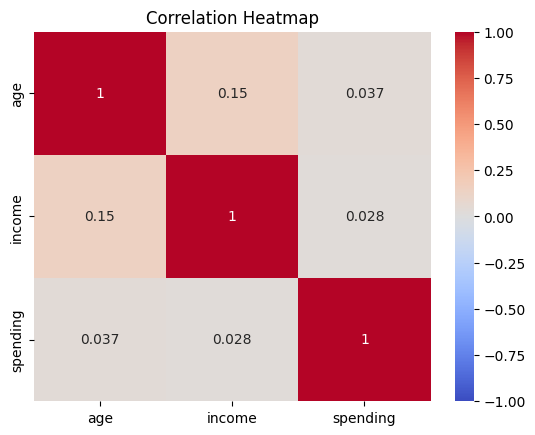

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(0)
df = pd.DataFrame({
    'age': np.random.randint(20, 60, 100),
    'income': np.random.randint(20000, 100000, 100),
    'spending': np.random.randint(1000, 20000, 100)
})
corr_matrix = df.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.show()

**Interpretation**: Darker red cells indicate strong positive correlation, darker blue cells indicate strong negative correlation, and lighter cells near zero indicate weak or no correlation — making relationships easy to spot at a glance.

## Visualization 1 — Correlation Types (Scatter Plots: Positive, Negative, No Correlation)

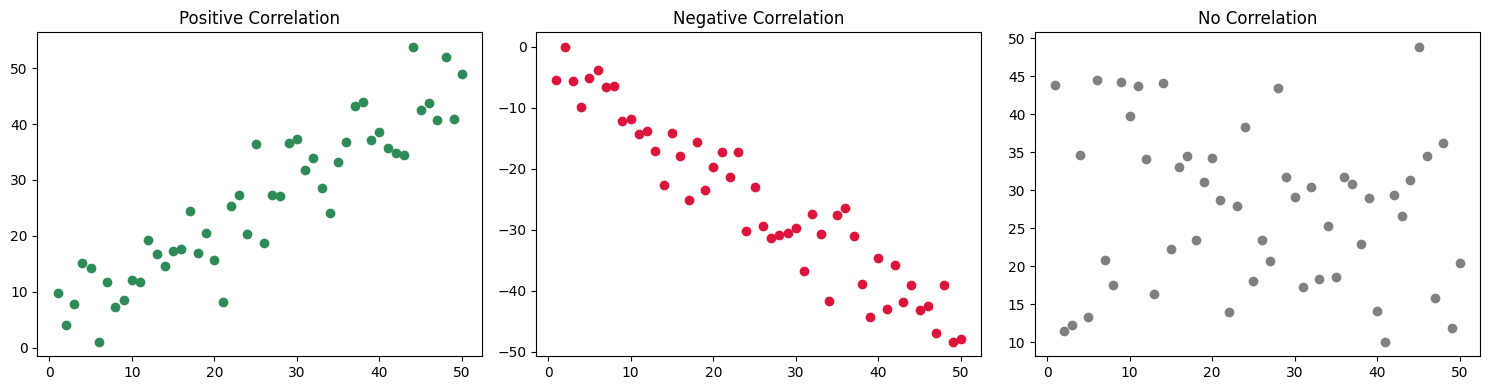

In [10]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
x = np.linspace(1, 50, 50)
pos_y = x + np.random.normal(0, 5, 50)
neg_y = -x + np.random.normal(0, 5, 50)
no_y = np.random.normal(25, 10, 50)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(x, pos_y, color='seagreen')
axes[0].set_title("Positive Correlation")
axes[1].scatter(x, neg_y, color='crimson')
axes[1].set_title("Negative Correlation")
axes[2].scatter(x, no_y, color='gray')
axes[2].set_title("No Correlation")
plt.tight_layout()
plt.show()

**Interpretation**: The first plot shows an upward trend (positive correlation), the second shows a downward trend (negative correlation), and the third shows scattered points with no clear pattern (no correlation).

## Visualization 2 — Correlation Matrix Heatmap

*(Heatmap topic itself serves as the second visualization — see code under Topic 09 above.)*

## Overall Advantages

- Quickly reveals relationships between variables without building a full model
- Helps in feature selection by identifying redundant or irrelevant variables
- Correlation matrices and heatmaps make multi-variable relationships easy to interpret visually
- Spearman correlation extends analysis to non-linear monotonic and ordinal data, adding robustness to outliers

## Overall Limitations

- Correlation does not imply causation — a strong correlation doesn't mean one variable causes the other
- Pearson correlation only captures linear relationships and is sensitive to outliers
- A correlation near zero doesn't rule out a strong non-linear relationship
- High correlation between features (multicollinearity) can destabilize certain models like linear regression if not addressed

## Interview Questions

**1. What is the difference between correlation and covariance?**
Covariance shows the direction of the relationship between two variables but is unscaled and hard to interpret in magnitude. Correlation is covariance normalized by the standard deviations of both variables, giving a standardized value between -1 and +1 that also indicates strength.

**2. Why does "correlation does not imply causation" matter in data science?**
Two variables can be strongly correlated due to a third confounding factor or pure coincidence, not because one causes the other. Assuming causation from correlation alone can lead to wrong business or model decisions.

**3. When would you use Spearman correlation instead of Pearson correlation?**
Spearman is used when data is ordinal, has outliers, or the relationship is monotonic but not linear, since it works on ranks rather than raw values. Pearson is used for continuous, roughly normal data with a linear relationship.

**4. How does multicollinearity affect a regression model, and how is correlation used to detect it?**
Multicollinearity occurs when predictor variables are highly correlated with each other, causing unstable and unreliable coefficient estimates in regression. A correlation matrix or heatmap is used to detect highly correlated feature pairs so one can be removed or combined.

**5. What does a correlation coefficient close to 0 actually tell you, and what doesn't it tell you?**
It tells you there is no linear relationship between the variables. It does not tell you there is no relationship at all — a strong non-linear (e.g., quadratic) relationship can still exist even with a correlation near zero.

**6. Why is a heatmap a preferred way to present a correlation matrix?**
A heatmap uses color intensity to make it instantly visible which variable pairs are strongly or weakly correlated across an entire dataset, which is much faster to interpret than scanning raw numbers in a table, especially with many variables.

## Self-Reflection

Working through correlation and covariance clarified how these concepts form the foundation of exploratory data analysis before any modeling begins. Understanding the distinction between Pearson and Spearman correlation highlighted the importance of checking data distribution and relationship type before choosing a metric, rather than defaulting to Pearson everywhere. Visualizing relationships through scatter plots and heatmaps reinforced that numbers alone can be misleading — visual inspection often reveals patterns (or the lack of them) more intuitively. Most importantly, this reinforced the critical distinction between correlation and causation, a mistake that's easy to make but can lead to seriously flawed conclusions in real-world analysis and ML feature selection.
